**TEAM MEMBERS AND DATASET**

Dataset: WFP HungerMap - Madagascar
Members:
- Marya LATIF 
- Raphaël MARQUES ARAUJO
- Faty LO
- François-Louis Legland
- Philippine LHOMME

## Import libraries

In [154]:
! pip install pandas
! pip install mlxtend
! pip install plotly
! pip install --upgrade nbformat


'pip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.
'pip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.
'pip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.
'pip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [155]:
! pip install prophet
! pip install mlxtend

'pip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.
'pip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [156]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
import statistics as st
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from prophet import Prophet
from sklearn.cluster import OPTICS
from sklearn.preprocessing import MinMaxScaler
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules



## Functions definitions

### Dataset exploration

In [157]:
def load_data(file_path):
    """
    Load CSV data and skip description row
    Input: file_path, path to CSV file
    Output: dataframe
    """
    print("======= Load & Display Data =======\n")
    
    # Read CSV and skip the second row (index 1)
    df = pd.read_csv(file_path)
    display(df.head())

    print("\n===skip description row===")
    df = pd.read_csv(file_path, skiprows=[1])
    display(df.head())
    
    # Display shape
    print(f"\n Data shape: {df.shape}")
    
    print("\n======= Summary statistics =======\n")
    display(df.describe())  
    
    print("\n======= DataFrame info =======\n")
    df.info()  
    
    return df

# Example usage
file_path = 'wfp-hungermap-data-for-mdg.csv'
df = load_data(file_path)

======= Load & Display Data =======



FileNotFoundError: [Errno 2] No such file or directory: 'wfp-hungermap-data-for-mdg.csv'

- About columns : countrycode and countryname have a unique value, we are studying data from a single country = Madagascar. Same for datatype, it's always a SURVEY.
- About data infos : We can see that almost all columns are non-zero, except for adminone and population. 
All types ar object, we going to adapt the type automatically

In [ ]:
def convert_types(df):
    """
    Convert columns to appropriate data types and remove unnecessary columns.
    
    - Remove unnecessary columns (countrycode, datatype, countryname)
    - Automatically detect text columns
    - Convert all other columns to numeric
    """
    # Remove unnecessary columns
    for col in ['countrycode', 'datatype', 'countryname']:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)
    
    # Automatically detect text columns (dtype = object)
    text_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    # Identify numeric columns (all except detected text columns)
    numeric_cols = [col for col in df.columns if col not in text_cols]
    
    # Convert numeric columns to numeric type (invalid values become NaN)
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    
    return df
convert_types(df)

,adminone,adminlevel,population,date,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,NaN,national,NaN,2024-03-04,8456947,0.322153,7816509,0.297757,2155430,0.082108,3180077,0.121140
1,NaN,national,NaN,2024-03-03,8604019,0.327756,7708249,0.293633,2185552,0.083255,3222276,0.122747
2,NaN,national,NaN,2024-03-02,8654571,0.329681,7845463,0.298860,2227397,0.084849,3284548,0.125119
3,NaN,national,NaN,2024-03-01,8597649,0.327513,7748351,0.295161,2175090,0.082856,3330646,0.126875
4,NaN,national,NaN,2024-02-29,8578497,0.326784,7827478,0.298175,2126254,0.080996,3322466,0.126564
...,...,...,...,...,...,...,...,...,...,...,...,...
1376,Menabe,subnational,711639.0,2024-01-05,99807,0.140249,178358,0.250630,71084,0.099888,91533,0.128623
1377,Sava,subnational,1178796.0,2024-01-05,477003,0.404653,253350,0.214923,158273,0.134267,144382,0.122483
1378,Sofia,subnational,1498769.0,2024-01-05,468533,0.312612,336681,0.224638,99133,0.066143,229278,0.152978
1379,Vakinankaratra,subnational,2167330.0,2024-01-05,891656,0.411408,662316,0.305591,229429,0.105858,327763,0.151229


### NaN Managment

In [ ]:
def check_missing_values(df):
    """
    Check missing values in the entire DataFrame.
    
    Parameters:
        df (DataFrame): The dataset
    
    Returns:
        DataFrame: Summary of missing values and their percentage
    """
    # Count missing values per column
    missing_count = df.isna().sum()
    
    # Calculate percentage of missing values
    missing_percent = (missing_count / len(df)) * 100
    
    # Combine into a DataFrame for better readability
    missing_summary = pd.DataFrame({
        'Missing Values': missing_count,
        'Percentage (%)': missing_percent.round(2)
    })
    
    # Print results
    print("Missing values summary:\n", missing_summary)
    
    return missing_summary
summary = check_missing_values(df)

Missing values summary:
                           Missing Values  Percentage (%)
adminone                              61            4.42
adminlevel                             0            0.00
population                            61            4.42
date                                   0            0.00
fcs people                             0            0.00
fcs prevalence                         0            0.00
rcsi people                            0            0.00
rcsi prevalence                        0            0.00
health access people                   0            0.00
health access prevalence               0            0.00
market access people                   0            0.00
market access prevalence               0            0.00


We note something interesting: since fcs people represents the number of people suffering from insufficient food consumption, and fcs prevalence represents the proportion of the population affected, we can directly deduce the population using these two quantities.

Indeed, by definition:
$$
fcs_{prevalence}
=
\frac{fcs_{people}}{population}
$$

so

$$
{population}
=
\frac{fcs_{people}}{fcs_{prevalence}}
$$

In [ ]:
def compute_population(fcs_people, fcs_prevalence):
    """
    Calculate population from FCS data
    Formula: population = fcs_people / fcs_prevalence
    Input: fcs_people (float), fcs_prevalence (float)
    Output: population (float)
    """
    return fcs_people / fcs_prevalence
    
def fulfill_population(df):
    """
    Fill missing population values using FCS formula
    Input: df (dataframe)
    Output: dataframe with filled population column
    """
    mask = df["population"].isna()
    df.loc[mask, "population"] = compute_population(
        df.loc[mask, "fcs people"],
        df.loc[mask, "fcs prevalence"]
    )
    display(df.isnull().sum())
    return df
df=fulfill_population(df)

adminone                    61
adminlevel                   0
population                   0
date                         0
fcs people                   0
fcs prevalence               0
rcsi people                  0
rcsi prevalence              0
health access people         0
health access prevalence     0
market access people         0
market access prevalence     0
dtype: int64

In [ ]:
df.head()

,adminone,adminlevel,population,date,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,NaN,national,2.625131e+07,2024-03-04,8456947,0.322153,7816509,0.297757,2155430,0.082108,3180077,0.121140
1,NaN,national,2.625131e+07,2024-03-03,8604019,0.327756,7708249,0.293633,2185552,0.083255,3222276,0.122747
2,NaN,national,2.625131e+07,2024-03-02,8654571,0.329681,7845463,0.298860,2227397,0.084849,3284548,0.125119
3,NaN,national,2.625131e+07,2024-03-01,8597649,0.327513,7748351,0.295161,2175090,0.082856,3330646,0.126875
4,NaN,national,2.625131e+07,2024-02-29,8578497,0.326784,7827478,0.298175,2126254,0.080996,3322466,0.126564


We can see that nothing has changed, so the errors were handled correctly during the conversion.

For numerical columns, we are going to use KNNImputer.

In [ ]:
def replace_NaN(df, columns):
    """
    Replace NaN values using KNN Imputer (4 neighbors)
    Input: df (dataframe), columns (list) - columns to impute
    Output: dataframe without NaN in specified columns
    """
    imputer = KNNImputer(n_neighbors=4, weights='uniform')
    df_no_nan = imputer.fit_transform(df[columns])
    df[columns] = pd.DataFrame(df_no_nan, columns=columns)
    return df
df = replace_NaN(df, ['population'])
df.isna().sum()

adminone                    61
adminlevel                   0
population                   0
date                         0
fcs people                   0
fcs prevalence               0
rcsi people                  0
rcsi prevalence              0
health access people         0
health access prevalence     0
market access people         0
market access prevalence     0
dtype: int64

### Using a modified Z-Score transformation for outlier detection

In [ ]:
def mad_z_score(tab):
    """
    Detect outliers using Modified Z-Score (MAD method)
    Input: tab (array) - values to check
    Output: list of outlier values
    """
    outliers = []
    mad = st.median([abs(val - st.median(tab)) for val in tab])
    for val in tab:
        if mad == 0:
            m = 0
        else:
            m = (0.6745 * (val - st.median(tab))) / mad
        if m > 3.5:
            outliers.append(val)
    return outliers

In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
for col in numeric_cols:
    outliers = mad_z_score(df[col])
    print(f"Outliers for {col} ({len(outliers)}): ", outliers)

Outliers for population (121):  [26251310.363586005, 26251310.36358601, 26251310.363586, 26251310.000000004, 26251310.0, 26251310.000000004, 26251310.0, 26251309.0389, 26251311.527185, 26251310.0, 26251310.0, 26251310.0, 26251310.000000004, 26251310.0, 26251310.000000004, 26251310.000000004, 26251310.000000004, 26251310.000000004, 26251310.0, 26251310.0, 26251310.000000004, 26251310.000000004, 26251310.000000004, 26251310.0, 26251310.0, 26251310.0, 26251310.000000007, 26251310.000000004, 26251310.000000007, 26251310.000000007, 26251310.0, 26251310.0, 26251310.532714, 26251309.651947003, 26251309.651947003, 26251310.0, 26251310.000000004, 26251310.000000004, 26251310.0, 26251310.0, 26251310.000000004, 26251310.000000004, 26251310.0, 26251310.0, 26251310.000000007, 26251310.000000004, 26251310.000000004, 26251310.841329, 26251310.000000004, 26251311.582561005, 26251310.000000007, 26251310.0, 26251310.000000004, 26251310.0, 26251309.999999996, 26251310.0, 26251310.000000004, 26251310.0, 2

- This seems to be a lot. We can see many values close to each other, which is not necessarily an outlier.

## Feature selection
| Colonne                | Description courte                                                      |
|------------------------|------------------------------------------------------------------------|
| countrycode            | Code du pays (souvent un code ISO ou un code standard pour pays)       |
| countryname            | Nom complet du pays                                                    |
| adminone               | Niveau administratif supérieur        |
| adminlevel             | Niveau administratif (indique le rang hiérarchique de adminone)       |
| population             | Population locale     |
| date                   | Date de la donnée           |
| datatype               | Type de données (nature des indicateurs mesurés)                       |
| fcs people             | Nombre de personnes avec un mauvais score "FCS" (food consomption score) that is to say the amount of people vulnerable to hunger  |
| fcs prevalence         |proportion de la population touchée par le FCS                                  |
| rcsi people            | Nombre de personnes concernées par le "RCSI" (peut être Reduced Coping Strategy Index ou autre indicateur) |
| rcsi prevalence        | Prévalence ou proportion liée au RCSI                                 |
| health access people   | Nombre de personnes ayant accès aux soins de santé                      |
| health access prevalence| Prévalence ou proportion de l'accès aux soins de santé                 |
| market access people   | Nombre de personnes ayant accès aux marchés                            |
| market access prevalence| Prévalence ou proportion de l'accès aux marchés                        |


### Let's display the correlation matrix to see which columns are relevant.

,population,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
population,1.000000,0.997302,0.024771,0.995490,-0.028115,0.995774,0.068317,0.993494,-0.019877
fcs people,0.997302,1.000000,0.084795,0.995377,0.005212,0.993882,0.080437,0.993977,0.008891
fcs prevalence,0.024771,0.084795,1.000000,0.052568,0.530508,0.039097,0.300384,0.067587,0.463501
rcsi people,0.995490,0.995377,0.052568,1.000000,0.034525,0.989731,0.067049,0.993047,0.007687
rcsi prevalence,-0.028115,0.005212,0.530508,0.034525,1.000000,-0.029332,0.083687,0.020907,0.472142
health access people,0.995774,0.993882,0.039097,0.989731,-0.029332,1.000000,0.138498,0.988708,-0.006796
health access prevalence,0.068317,0.080437,0.300384,0.067049,0.083687,0.138498,1.000000,0.084380,0.336138
market access people,0.993494,0.993977,0.067587,0.993047,0.020907,0.988708,0.084380,1.000000,0.073520
market access prevalence,-0.019877,0.008891,0.463501,0.007687,0.472142,-0.006796,0.336138,0.073520,1.000000


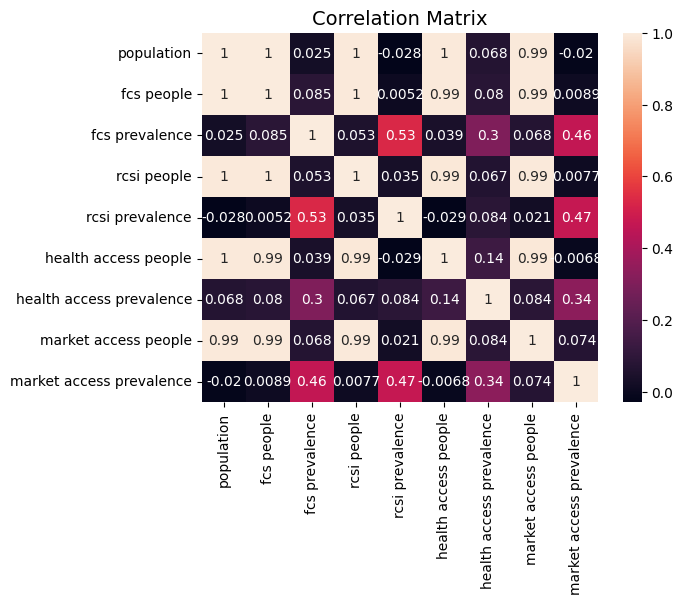

In [ ]:
def plot_correlation_matrix(df):
    """
    Display correlation matrix heatmap for all numeric columns in the DataFrame.
    
    Input:
        df (DataFrame): The dataset
    Output:
        None (displays plot)
    """
    # Automatically select numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    
    # Compute correlation matrix
    corr_matrix = df[numeric_cols].corr()
    display(corr_matrix)
    # Plot heatmap
    sns.heatmap(corr_matrix, annot=True)
    plt.title("Correlation Matrix", fontsize=14)
    plt.show()
plot_correlation_matrix(df)

#### Feature Selection - Decision

**Correlation Analysis Result**
The correlation matrix revealed that all `*_people` columns are highly correlated (r=0.99):
- `fcs people`
- `rcsi people`
- `health access people`
- `market access people`

**potential Decision**
We chose to KEEP all 4 columns despite high correlation for the following reasons:

1. Dashboard flexibility: Allows users to select which indicator to visualize
2. Comparative analysis: Enables side-by-side comparison of indicators
3. Interpretability: Each indicator has distinct policy meaning:
   - `fcs people`: Food consumption issues
   - `rcsi people`: Coping strategies usage
   - `health access people`: Healthcare access barriers
   - `market access people`: Market access barriers

4. Statistical consideration : While correlated, they measure slightly different aspects of vulnerability


**Recommendation**
Keep only one `*_people` variable and remove the other 3

Keep all `*_prevalence` variables:
- Moderate correlations are acceptable (0.34-0.53)

Keep `population`:
- Low correlations with other variables (<0.3)
- Independent information

### Trade-off
- Advantage: Richer analysis and visualizations
- Disadvantage: Potential multicollinearity in predictive models

**Note:** For machine learning models, we would use only `fcs people` to avoid multicollinearity.

In [ ]:
df

,adminone,adminlevel,population,date,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,NaN,national,2.625131e+07,2024-03-04,8456947,0.322153,7816509,0.297757,2155430,0.082108,3180077,0.121140
1,NaN,national,2.625131e+07,2024-03-03,8604019,0.327756,7708249,0.293633,2185552,0.083255,3222276,0.122747
2,NaN,national,2.625131e+07,2024-03-02,8654571,0.329681,7845463,0.298860,2227397,0.084849,3284548,0.125119
3,NaN,national,2.625131e+07,2024-03-01,8597649,0.327513,7748351,0.295161,2175090,0.082856,3330646,0.126875
4,NaN,national,2.625131e+07,2024-02-29,8578497,0.326784,7827478,0.298175,2126254,0.080996,3322466,0.126564
...,...,...,...,...,...,...,...,...,...,...,...,...
1376,Menabe,subnational,7.116390e+05,2024-01-05,99807,0.140249,178358,0.250630,71084,0.099888,91533,0.128623
1377,Sava,subnational,1.178796e+06,2024-01-05,477003,0.404653,253350,0.214923,158273,0.134267,144382,0.122483
1378,Sofia,subnational,1.498769e+06,2024-01-05,468533,0.312612,336681,0.224638,99133,0.066143,229278,0.152978
1379,Vakinankaratra,subnational,2.167330e+06,2024-01-05,891656,0.411408,662316,0.305591,229429,0.105858,327763,0.151229


### Let's now build some visualization to get some insights from the data

We convert the dates into the write format

In [ ]:
def transform_datetime(df, date_col='date'):
    """
    Convert date column to datetime format
    Input: df (dataframe), date_col (str) - name of date column
    Output: dataframe with datetime column
    """
    df[date_col] = pd.to_datetime(df[date_col])
    return df
df=transform_datetime(df)
print(df["date"].dtype)

datetime64[ns]


In [ ]:
df["date"].min()

Timestamp('2023-12-04 00:00:00')

We notice that we have an isolated date

In [ ]:
def drop_outliers(df, column, outliers):
    """
    Remove outlier rows from dataframe
    Input: df (dataframe), column (str), outliers (list) - values to remove
    Output: dataframe without outliers
    """
    mask = df[column].isin(outliers)
    return df[~mask]


df = drop_outliers(df, "date", ["2023-12-04 00:00:00"])
df.head()

/tmp/ipykernel_20590/2759168297.py:7: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  mask = df[column].isin(outliers)


,adminone,adminlevel,population,date,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,NaN,national,2.625131e+07,2024-03-04,8456947,0.322153,7816509,0.297757,2155430,0.082108,3180077,0.121140
1,NaN,national,2.625131e+07,2024-03-03,8604019,0.327756,7708249,0.293633,2185552,0.083255,3222276,0.122747
2,NaN,national,2.625131e+07,2024-03-02,8654571,0.329681,7845463,0.298860,2227397,0.084849,3284548,0.125119
3,NaN,national,2.625131e+07,2024-03-01,8597649,0.327513,7748351,0.295161,2175090,0.082856,3330646,0.126875
4,NaN,national,2.625131e+07,2024-02-29,8578497,0.326784,7827478,0.298175,2126254,0.080996,3322466,0.126564


In [ ]:
df.dropna(inplace=True)
df.head()

/tmp/ipykernel_20590/3523028469.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


,adminone,adminlevel,population,date,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
61,Alaotra Mangoro,subnational,1234447.0,2024-03-04,291455,0.236102,278704,0.225772,28167,0.022818,105450,0.085423
62,Amoron I Mania,subnational,859365.0,2024-03-04,370973,0.431683,295194,0.343502,44835,0.052172,73579,0.085620
63,Analamanga,subnational,4024795.0,2024-03-04,937266,0.232873,1237495,0.307468,481836,0.119717,358509,0.089075
64,Analanjirofo,subnational,1244087.0,2024-03-04,261716,0.210368,243557,0.195772,63114,0.050731,73503,0.059082
65,Androy,subnational,882088.0,2024-03-04,400983,0.454584,322623,0.365749,96278,0.109148,264186,0.299501


In [ ]:
df['adminlevel'].unique()

array(['subnational'], dtype=object)

In [ ]:
df.drop(columns=["adminlevel"],inplace=True)

/tmp/ipykernel_20590/935762244.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["adminlevel"],inplace=True)


In [ ]:
def plot_box_fcs(df):
    fig = px.box(
        df,
        x="fcs people",
        color="adminone",
        title="Distribution of FCS by Adminone"
    )
    fig.update_layout(
        xaxis_title="FCS People",
        yaxis_title="Distribution",
        legend_title="Adminone",
        template="plotly_white"
    )
    fig.show()

# Appel de la fonction
plot_box_fcs(df)

In [ ]:
def aggregate_by_date(df, date_col, agg_dict):
    """
    Aggregate data by date with specified aggregation functions.
    
    Parameters:
        df (DataFrame): The dataset
        date_col (str): Column name for date
        agg_dict (dict): Dictionary of {column: aggregation function}
    
    Returns:
        DataFrame: Aggregated by date
    """
    grouped = df.groupby(date_col).agg(agg_dict).reset_index()
    return grouped

#  usage:
agg_dict = {
    "fcs people": "sum",
    "rcsi people": "sum",
    "health access people": "sum",
    "market access people": "sum"
}

popul_grouped = aggregate_by_date(df, "date", agg_dict)
popul_grouped.head()

,date,fcs people,rcsi people,health access people,market access people
0,2024-01-05,8792908,6748693,2333131,3225117
1,2024-01-06,8768623,6768154,2313100,3208684
2,2024-01-07,8637837,6651572,2317579,3262870
3,2024-01-08,8523043,6566154,2288343,3223801
4,2024-01-09,8420603,6550754,2271646,3249007


In [ ]:
def plot_scatter_fcs(popul_grouped):
    fig = px.scatter(
        popul_grouped,
        x="date",
        y="fcs people",
        title="FCS People Over Time"
    )
    fig.update_layout(
        xaxis_title="Date",
        yaxis_title="FCS People",
        template="plotly_white"
    )
    fig.show()

# Appel de la fonction
plot_scatter_fcs(popul_grouped)


In [ ]:
def visualize_temporal_evolution(df, date_col, value_cols, title):
    """
    Create line chart for temporal evolution of multiple indicators
    Input: df (dataframe), date_col (str), value_cols (list), title (str)
    Output: Plotly figure
    """
    fig = px.line(df, x=date_col, y=value_cols, title=title)
    return fig


fig = visualize_temporal_evolution(
    popul_grouped,
    date_col="date",
    value_cols=["fcs people", "rcsi people", "health access people", "market access people"],
    title="Food Security Indicators Over Time"
)
fig.show()


In [ ]:
def visualize_area_chart(df, date_col, value_col, title):
    """
    Create area chart for single indicator
    Input: df (dataframe), date_col (str), value_col (str), title (str)
    Output: Plotly figure
    """
    fig = px.area(df, x=date_col, y=value_col, title=title)
    return fig
fig = visualize_area_chart(
    popul_grouped,
    date_col="date",
    value_col="fcs people",
    title="Number of People with Insufficient Food Consumption"
)
fig.show()

In [ ]:
def visualize_subplots_4indicators(df, date_col, indicators):
    """
    Create 2x2 subplots for 4 indicators
    Input:
        df (DataFrame): Data source
        date_col (str): Column name for dates
        indicators (list): List of 4 column names
    Output:
        Plotly Figure
    """
    fig = make_subplots(rows=2, cols=2, subplot_titles=indicators)

    fig.add_trace(go.Scatter(x=df[date_col], y=df[indicators[0]], mode='lines'), row=1, col=1)
    fig.add_trace(go.Scatter(x=df[date_col], y=df[indicators[1]], mode='lines'), row=1, col=2)
    fig.add_trace(go.Scatter(x=df[date_col], y=df[indicators[2]], mode='lines'), row=2, col=1)
    fig.add_trace(go.Scatter(x=df[date_col], y=df[indicators[3]], mode='lines'), row=2, col=2)

    fig.update_layout(height=600, width=900,
                      title="Food Security Indicators Over Time",
                      showlegend=False,
                      template="plotly_white")
    return fig

# Exemple d'utilisation
fig = visualize_subplots_4indicators(
    popul_grouped,
    date_col="date",
    indicators=["fcs people", "rcsi people", "health access people", "market access people"]
)
fig.show()

In [ ]:
def aggregate_by_date_region(df, date_col, region_col, value_col):
    """
    Aggregate data by date and region for a specific indicator.
    Input:
        df (DataFrame): Data source
        date_col (str): Column name for dates
        region_col (str): Column name for regions
        value_col (str): Column name for the indicator
    Output:
        DataFrame grouped by date and region
    """
    grouped = df.groupby([date_col, region_col]).agg({value_col: 'sum'}).reset_index()
    return grouped

In [ ]:
def visualize_stacked_bar_by_region(grouped_df, date_col, region_col, value_col, title):
    """
    Create stacked bar chart showing regional contributions over time.
    Input:
        grouped_df (DataFrame): Already aggregated by date and region
        date_col (str): Column name for dates
        region_col (str): Column name for regions
        value_col (str): Column name for the indicator
        title (str): Chart title
    Output:
        Plotly Figure
    """
    # Pivot for stacked bar
    pivot = grouped_df.pivot(index=date_col, columns=region_col, values=value_col)

    # Create stacked bar chart
    fig = px.bar(pivot, x=pivot.index, y=pivot.columns, title=title)
    fig.update_layout(barmode="stack", xaxis_title="Date", yaxis_title=value_col, template="plotly_white")

    return fig


grouped = aggregate_by_date_region(df, "date", "adminone", "fcs people")

fig = visualize_stacked_bar_by_region(
    grouped,
    date_col="date",
    region_col="adminone",
    value_col="fcs people",
    title="FCS People by Region Over Time"
)
fig.show()

In [ ]:
def visualize_line_by_region(df, date_col, region_col, value_col, title):
    """
    Create a line chart showing the evolution of one indicator by region over time.
    Input:
        df (DataFrame): Data source
        date_col (str): Column name for dates
        region_col (str): Column name for regions
        value_col (str): Column name for the indicator
        title (str): Chart title
    Output:
        Plotly Figure
    """
    fig = px.line(df, x=date_col, y=value_col, color=region_col, title=title)
    return fig

# Exemple d'utilisation
fig = visualize_line_by_region(
    grouped,
    date_col="date",
    region_col="adminone",
    value_col="fcs people",
    title="FCS People by Region Over Time"
)
fig.show()

In [ ]:
def visualize_treemap_snapshot(df, date, region_col, value_col, title):
    """
    Create treemap showing regional distribution at a specific date
    Input: df (dataframe), date (str), region_col (str), value_col (str), title (str)
    Output: Plotly figure
    """
    df_date = df[df["date"] == date]
    fig = px.treemap(df_date, path=[region_col], values=value_col, title=title)
    return fig

date = "2024-01-05"
fig = visualize_treemap_snapshot(
    grouped,
    date=date,
    region_col="adminone",
    value_col="fcs people",
    title=f"FCS People by Region — {date}")

fig.show()

### Forecasting 

Prévoir l’évolution du nombre de personnes en insécurité alimentaire dans les jours et semaines à venir

In [ ]:
def prepare_for_prophet(df, date_col, value_col):
    """
    Prepare data for Prophet forecasting algorithm
    Prophet requires columns named 'ds' (date) and 'y' (value)
    Input: df (dataframe), date_col (str), value_col (str)
    Output: dataframe with 'ds' and 'y' columns
    """
    df_prophet = df[[date_col, value_col]].copy()
    df_prophet.columns = ['ds', 'y']
    return df_prophet

In [ ]:
def forecast_with_prophet(df_prophet, periods=30):
    """
    Forecast future values using Facebook Prophet algorithm
    Input: df_prophet (dataframe with 'ds' and 'y'), periods (int) - days to predict
    Output: model (Prophet object), prediction (dataframe)
    """
    # Create model with 95% confidence interval
    model = Prophet(interval_width=0.95)
    
    # Train model
    model.fit(df_prophet)
    
    # Create future dates
    future_dates = model.make_future_dataframe(periods=periods, freq='D')
    
    # Predict
    prediction = model.predict(future_dates)
    
    return model, prediction

In [ ]:

def visualize_forecast(df_original, prediction, title="Forecast"):
    """
    Visualize original time series + predictions with confidence interval
    """
    fig = go.Figure()

    # Observed data
    fig.add_trace(go.Scatter(
        x=df_original['ds'], y=df_original['y'],
        mode='lines', name='Observed data',
        line=dict(color='blue', width=2)
    ))

    # Forecast
    fig.add_trace(go.Scatter(
        x=prediction['ds'], y=prediction['yhat'],
        mode='lines', name='Forecast',
        line=dict(color='red', dash='dash', width=2)
    ))

    # Upper bound (invisible)
    fig.add_trace(go.Scatter(
        x=prediction['ds'], y=prediction['yhat_upper'],
        mode='lines', line=dict(width=0), showlegend=False
    ))

    # Lower bound + fill
    fig.add_trace(go.Scatter(
        x=prediction['ds'], y=prediction['yhat_lower'],
        mode='lines', line=dict(width=0),
        fill='tonexty', fillcolor='rgba(255,0,0,0.2)',
        name='Confidence interval (95%)'
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Date",
        yaxis_title="Number of people (FCS)",
        hovermode='x unified',
        height=500,
        template="plotly_white"
    )
    return fig


In [ ]:

# 1) Préparer les données pour Prophet
df_prophet = prepare_for_prophet(popul_grouped, date_col="date", value_col="fcs people")

# 2) Entraîner et prédire 30 jours
model, prediction = forecast_with_prophet(df_prophet, periods=30)

# 3) Visualiser

fig = visualize_forecast(df_prophet, prediction, title="FCS People Forecast")
fig.show()


01:03:05 - cmdstanpy - INFO - Chain [1] start processing
01:03:06 - cmdstanpy - INFO - Chain [1] done processing


#### Interprétation

**Ce que montre le graphique**  
Le graphique présente l’évolution du nombre de personnes avec un **Food Consumption Score insuffisant** entre janvier et mars 2024.

- Bleu : Données observées jusqu’à fin février.
- Rouge pointillé : Prévision pour mars.
- Zone rouge claire : Intervalle de confiance à 95 %, illustrant l’incertitude.

**Ce qu’on observe**  
Entre janvier et février, le nombre de personnes commence à 8,6 M, monte légèrement à 8,8 M, atteint un pic à 9 M début février, puis redescend vers 8,4 M fin février.  
Pour mars, la prévision indique une stabilisation autour de 8,3 M, mais avec une forte incertitude : le scénario haut pourrait atteindre 9,5 M, tandis que le scénario bas descendrait à 7 M.

**Ce que ça veut dire**  
La situation semble stable, mais le risque de forte détérioration ou amélioration reste présent.  
Pour la planification, il est recommandé de prévoir des ressources pour le scénario pessimiste (environ 9,5 M) et de renforcer la surveillance, car l’incertitude est importante.


###  SPATIAL CLUSTERING FUNCTIONS 

### Clustering

Identifier les régions qui ont des profils de vulnérabilité similaires pour organiser les interventions 

In [ ]:
def aggregate_by_region(df, region_col='adminone'):
    """
    Aggregate food security indicators by administrative region
    Input: df (dataframe), region_col (str)
    Output: dataframe aggregated by region
    """
    regional_data = df.groupby(region_col).agg({
        'fcs prevalence': 'mean',
        'rcsi prevalence': 'mean',
        'health access prevalence': 'mean',
        'market access prevalence': 'mean',
        'population': 'mean'
    }).reset_index()
    return regional_data

def spatial_clustering(df, features_cols):
    """
    Apply OPTICS clustering 
    Input: df (dataframe), features_cols (list)
    Output: dataframe with 'cluster' column
    """
    X = df[features_cols].values
    optics_model = OPTICS(min_samples=2, xi=0.05, min_cluster_size=0.1)
    df['cluster'] = optics_model.fit_predict(X)
    return df

def visualize_clusters_bar(df, region_col='adminone'):
    """
    Bar chart of clusters
    Input: df (dataframe), region_col (str)
    Output: Plotly figure
    """
    df['cluster'] = df['cluster'].astype(str)
    fig = px.bar(df, x=region_col, y='fcs prevalence', color='cluster',
                 title='Regional Clustering by Vulnerability Profile')
    fig.update_layout(xaxis_tickangle=-45, height=500, template="plotly_white")
    return fig

def visualize_clusters_scatter(df):
    """
    Scatter plot of clusters (FCS vs rCSI)
    Input: df (dataframe)
    Output: Plotly figure
    """
    df['cluster'] = df['cluster'].astype(str)
    fig = px.scatter(df, x='fcs prevalence', y='rcsi prevalence', 
                     color='cluster', size='population', hover_name='adminone',
                     title='Regional Clusters (FCS vs rCSI)')
    fig.update_layout(height=500, template="plotly_white")
    return fig

In [ ]:
# 1. Agréger par région
regional_data = aggregate_by_region(df, 'adminone')
display(regional_data.head())

# 2. Définir les features pour le clustering
clustering_features = ['fcs prevalence', 'rcsi prevalence', 
                      'health access prevalence', 'market access prevalence']

# 3. Appliquer OPTICS
regional_clustered = spatial_clustering(regional_data, clustering_features)
print(regional_clustered[['adminone', 'cluster']])

# 4. Visualiser - Bar chart
fig_bar = visualize_clusters_bar(regional_clustered, 'adminone')
fig_bar.show()

,adminone,fcs prevalence,rcsi prevalence,health access prevalence,market access prevalence,population
0,Alaotra Mangoro,0.200899,0.250573,0.049130,0.081785,1234447.0
1,Amoron I Mania,0.430244,0.301818,0.079405,0.063414,859365.0
2,Analamanga,0.281576,0.228026,0.109211,0.077268,4024795.0
3,Analanjirofo,0.274160,0.216751,0.078948,0.102272,1244087.0
4,Androy,0.466242,0.352888,0.106889,0.294162,882088.0


               adminone  cluster
0       Alaotra Mangoro       -1
1        Amoron I Mania        3
2            Analamanga        1
3          Analanjirofo        1
4                Androy       -1
5                 Anosy       -1
6      Atsimo Andrefana       -1
7     Atsimo Atsinanana        5
8            Atsinanana        2
9             Betsiboka        0
10                Boeny        4
11            Bongolava        0
12                Diana       -1
13      Haute Matsiatra        3
14             Ihorombe        3
15                Itasy        1
16               Melaky        0
17               Menabe        4
18                 Sava        2
19                Sofia        2
20       Vakinankaratra        2
21  Vatovavy Fitovinany        5


**Interprétation :**
Ce graphique montre la prévalence FCS (Food Consumption Score) par région, avec des couleurs indiquant les clusters identifiés par l’algorithme OPTICS.  
- Les régions sont regroupées selon leur profil de vulnérabilité alimentaire.  
  - **Cluster 5** : Régions avec FCS très élevé ==> zones prioritaires.
  - **Cluster 4** : Régions avec FCS faible ==> zones moins critiques.
- Les régions marquées `-1` sont des cas atypiques (bruit), nécessitant une analyse spécifique.

In [ ]:
# 5. Visualiser - Scatter plot
fig_scatter = visualize_clusters_scatter(regional_clustered)
fig_scatter.show()

**Interprétation :**
Ce graphique compare deux indicateurs clés :  
- Axe X : FCS prevalence (insécurité alimentaire).  
- Axe Y : rCSI prevalence (stratégies de survie).  
- Taille des bulles : Population régionale.  
- Couleur : Cluster OPTICS.  

On observe une corrélation : les régions avec un FCS élevé ont souvent un rCSI élevé.  
- Les points en haut à droite (fort FCS + fort rCSI) représentent les zones les plus vulnérables.  
- Les clusters 5 et 3 regroupent ces zones critiques, tandis que le cluster 0 et 4 correspondent à des régions relativement stables.  
- Les points `-1` indiquent des profils atypiques.

In [ ]:
#PT1

def Encoder_Transcactions(dataset):
    te = TransactionEncoder()
    te_ary = te.fit(dataset).transform(dataset)
    df = pd.DataFrame(te_ary, columns=te.columns_)
    return df


def extract_patterns(df, min_support=0.6):
    patterns = apriori(df, min_support=min_support, use_colnames=True)
    print("Frequent Itemsets:\n", patterns)
    return patterns


def analyze_support_effect(df):

    supports = [0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15]
    num_patterns = []

    for s in supports:
        frequent_itemsets = apriori(df, min_support=s, use_colnames=True)
        num_patterns.append(len(frequent_itemsets))



    plt.figure(figsize=(8,5))
    plt.plot(supports, num_patterns, marker='o')
    plt.xlabel('Minimal Support')
    plt.ylabel('Number of Patterns')
    plt.title('Effect of Minimal Support on Number of Patterns')
    plt.gca().invert_xaxis()  
    plt.grid(True)
    plt.show()
    print("Explain phenomenom")

    return "Explain phenomenom"


def extract_rules(patterns):
    ar = association_rules(patterns, metric="lift", min_threshold=1)
    # For new versions, add a new parameter with the value "len(dataframe)"
    return ar
    

#EX2


"""
all_items = sorted(set(item for transaction in superdf for item in transaction))
encoded_vals = []
for transaction in superdf:
    encoded_vals.append([1 if item in transaction else 0 for item in all_items])
df = pd.DataFrame(encoded_vals, columns=all_items)

# Step 1: Find frequent itemsets with minimum support of 0.6

patterns = apriori(df, min_support=0.6, use_colnames=True)
print("Frequent Itemsets:\n", patterns)

# Step 2: Generate association rules using lift as metric (min_threshold=1)

rules = association_rules(patterns, metric="lift", min_threshold=1)
print("\nAssociation Rules:\n", rules)

# Step 3: Display specific information

# Antecedents of the rules

print("\nAntecedents of rules:\n", rules['antecedents'])

# Rules with support > 0.6

high_support_rules = rules.loc[rules['support'] > 0.6]
print("\nRules with support > 0.6:\n", high_support_rules)


"""
#Ex3

# Step 1: Create a list of all distinct nodes (individual items only)
def list_nodes(ar):
    allnodes = sorted(list(set().union(
        *[set(antecedent) for antecedent in ar['antecedents']],
        *[set(consequent) for consequent in ar['consequents']]
    )))

    print("All Nodes:", allnodes)
    print("Nombre de noeuds:", len(allnodes))
    return allnodes


# Step 2: Create source_indices and target_indices for each rule
def create_sankey_indices(ar, allnodes):
    source_indices = []
    target_indices = []
    conf_values = []

    for idx, row in ar.iterrows():
        antecedent = list(row['antecedents'])
        consequent = list(row['consequents'])
        
        if len(antecedent) > 0 and len(consequent) > 0:
            # Get the first item from antecedent and consequent
            source_idx = allnodes.index(antecedent[0])
            target_idx = allnodes.index(consequent[0])
            
            source_indices.append(source_idx)
            target_indices.append(target_idx)
            conf_values.append(row['confidence'])
    
    return source_indices, target_indices, conf_values


# Verify lengths
def verify_lengths(source_indices, target_indices, conf_values):
    len_source = len(source_indices)
    len_target = len(target_indices)
    len_conf = len(conf_values)
    
    print(f"Length of source_indices: {len_source}")
    print(f"Length of target_indices: {len_target}")
    print(f"Length of conf_values: {len_conf}")
    
    if len_source == len_target == len_conf:
        print("All lists have the same length.")
    else:
        print("Lists have different lengths.")

# Sankey diagram 
def visualize_sankey(source_indices, target_indices, conf_values, allnodes):
    fig = go.Figure(data=[go.Sankey(
        node = dict(
            #pad = 15,
            label = allnodes, # Here we use the index of different items or itemsets
            color = "red", # the color of nodes
        ),
        link = dict(
            #arrowlen = 15,
            source = source_indices, # our list of indices of antecedent set
            target = target_indices, # our list of indices of consequent set
            value = conf_values, # our list of confidence for each rule (16)
        ))])
    fig.show(renderer="browser")
    return fig 


           adminone  population       date  fcs people  fcs prevalence  \
61  Alaotra Mangoro   1234447.0 2024-03-04      291455        0.236102   
62   Amoron I Mania    859365.0 2024-03-04      370973        0.431683   
63       Analamanga   4024795.0 2024-03-04      937266        0.232873   
64     Analanjirofo   1244087.0 2024-03-04      261716        0.210368   
65           Androy    882088.0 2024-03-04      400983        0.454584   

    rcsi people  rcsi prevalence  health access people  \
61       278704         0.225772                 28167   
62       295194         0.343502                 44835   
63      1237495         0.307468                481836   
64       243557         0.195772                 63114   
65       322623         0.365749                 96278   

    health access prevalence  market access people  market access prevalence  
61                  0.022818                105450                  0.085423  
62                  0.052172                 735

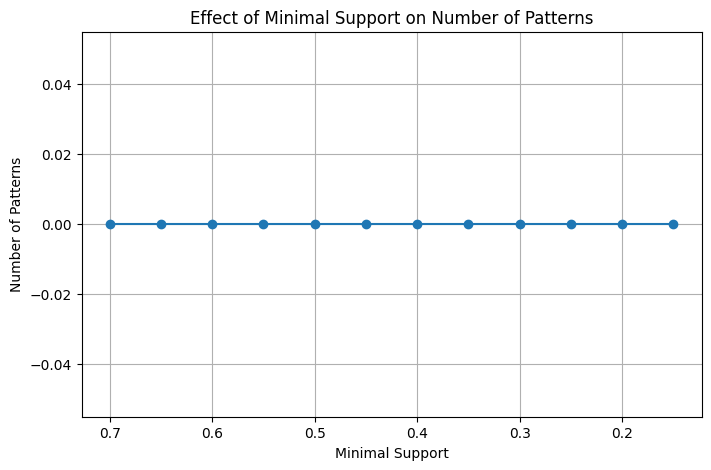

Explain phenomenom


ValueError: The input DataFrame `df` containing the frequent itemsets is empty.

In [ ]:
#PT1

df3 = Encoder_Transcactions(df2)
print(df2.head())
print(df3.head())

patterns = extract_patterns(df3, min_support=0.6)

analyze_support_effect(df3)

ar = extract_rules(patterns)

    


# Step 1: Create a list of all distinct nodes (individual items only)
allnodes = list_nodes(ar)


# Step 2: Create source_indices and target_indices for each rule
source_indices, target_indices, conf_values = create_sankey_indices(ar, allnodes)


# Verify lengths
verify_lengths(source_indices, target_indices, conf_values)


# Sankey diagram 
visualize_sankey(source_indices, target_indices, conf_values, allnodes)



WFP HUNGERMAP - MADAGASCAR ANALYSIS

[STEP 1] Loading data...
======= Load & Display Data =======



,countrycode,countryname,adminone,adminlevel,population,date,datatype,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,#country+code,#country+name,#adm1+name,#meta+adminlevel,#population+total,#date,#data+type,#population+fcs,#indicator+fcs+prevalence,#population+rcsi,#indicator+rcsi+prevalence,#population+health_access,#indicator+health_access+prevalence,#population+market_access,#indicator+market_access+prevalence
1,MDG,Madagascar,NaN,national,NaN,2024-03-04,SURVEY,8456947,0.32215332807656305,7816509,0.2977569119407755,2155430,0.08210751797908643,3180077,0.12113974014886676
2,MDG,Madagascar,NaN,national,NaN,2024-03-03,SURVEY,8604019,0.32775579126651516,7708249,0.2936329211224791,2185552,0.08325496662992705,3222276,0.1227472490461335
3,MDG,Madagascar,NaN,national,NaN,2024-03-02,SURVEY,8654571,0.3296814856147151,7845463,0.29885986642190426,2227397,0.08484898329823913,3284548,0.12511939962610666
4,MDG,Madagascar,NaN,national,NaN,2024-03-01,SURVEY,8597649,0.327513141248951,7748351,0.2951605462736907,2175090,0.08285642813079001,3330646,0.12687541988738874



===skip description row===


,countrycode,countryname,adminone,adminlevel,population,date,datatype,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
0,MDG,Madagascar,NaN,national,NaN,2024-03-04,SURVEY,8456947,0.322153,7816509,0.297757,2155430,0.082108,3180077,0.121140
1,MDG,Madagascar,NaN,national,NaN,2024-03-03,SURVEY,8604019,0.327756,7708249,0.293633,2185552,0.083255,3222276,0.122747
2,MDG,Madagascar,NaN,national,NaN,2024-03-02,SURVEY,8654571,0.329681,7845463,0.298860,2227397,0.084849,3284548,0.125119
3,MDG,Madagascar,NaN,national,NaN,2024-03-01,SURVEY,8597649,0.327513,7748351,0.295161,2175090,0.082856,3330646,0.126875
4,MDG,Madagascar,NaN,national,NaN,2024-02-29,SURVEY,8578497,0.326784,7827478,0.298175,2126254,0.080996,3322466,0.126564



 Data shape: (1381, 15)

======= Summary statistics =======



,population,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
count,1.320000e+03,1.381000e+03,1381.000000,1.381000e+03,1381.000000,1.381000e+03,1381.000000,1.381000e+03,1381.000000
mean,1.193241e+06,7.608201e+05,0.325185,6.230508e+05,0.275245,2.001989e+05,0.082179,2.809448e+05,0.124619
std,7.698637e+05,1.725474e+06,0.099883,1.414499e+06,0.068609,4.575622e+05,0.031464,6.369537e+05,0.055015
min,3.480530e+05,4.960400e+04,0.126463,8.473300e+04,0.081430,4.938000e+03,0.012154,2.163200e+04,0.036112
25%,8.074180e+05,1.765190e+05,0.240862,1.763340e+05,0.229417,6.330500e+04,0.055626,6.821600e+04,0.081739
50%,1.020608e+06,3.707970e+05,0.322752,2.850400e+05,0.273562,8.345200e+04,0.086711,1.295850e+05,0.116571
75%,1.498769e+06,5.642620e+05,0.413205,4.093540e+05,0.300311,1.289870e+05,0.105396,2.172740e+05,0.146769
max,4.024795e+06,9.503583e+06,0.548083,8.031839e+06,0.535283,2.573170e+06,0.184598,3.578953e+06,0.345412



======= DataFrame info =======

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1381 entries, 0 to 1380
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   countrycode               1381 non-null   object 
 1   countryname               1381 non-null   object 
 2   adminone                  1320 non-null   object 
 3   adminlevel                1381 non-null   object 
 4   population                1320 non-null   float64
 5   date                      1381 non-null   object 
 6   datatype                  1381 non-null   object 
 7   fcs people                1381 non-null   int64  
 8   fcs prevalence            1381 non-null   float64
 9   rcsi people               1381 non-null   int64  
 10  rcsi prevalence           1381 non-null   float64
 11  health access people      1381 non-null   int64  
 12  health access prevalence  1381 non-null   float64
 13  market access people      1381

adminone                    61
adminlevel                   0
population                   0
date                         0
fcs people                   0
fcs prevalence               0
rcsi people                  0
rcsi prevalence              0
health access people         0
health access prevalence     0
market access people         0
market access prevalence     0
dtype: int64

✓ Population calculated from FCS data
✓ NaN values imputed with KNN
✓ Dates converted to datetime format
✓ Outlier date removed
✓ Cleaned data: 1320 rows, 11 columns

[STEP 3] Exploratory Data Analysis...


,population,fcs people,fcs prevalence,rcsi people,rcsi prevalence,health access people,health access prevalence,market access people,market access prevalence
population,1.000000,0.896582,0.085125,0.889291,-0.107196,0.910811,0.241089,0.722988,-0.074441
fcs people,0.896582,1.000000,0.478543,0.893831,0.117288,0.838500,0.311803,0.797661,0.121355
fcs prevalence,0.085125,0.478543,1.000000,0.279746,0.531410,0.138261,0.300098,0.383054,0.463961
rcsi people,0.889291,0.893831,0.279746,1.000000,0.306348,0.803036,0.239139,0.807435,0.117786
rcsi prevalence,-0.107196,0.117288,0.531410,0.306348,1.000000,-0.084554,0.084671,0.232223,0.472812
health access people,0.910811,0.838500,0.138261,0.803036,-0.084554,1.000000,0.547409,0.677616,0.011520
health access prevalence,0.241089,0.311803,0.300098,0.239139,0.084671,0.547409,1.000000,0.351690,0.336748
market access people,0.722988,0.797661,0.383054,0.807435,0.232223,0.677616,0.351690,1.000000,0.566557
market access prevalence,-0.074441,0.121355,0.463961,0.117786,0.472812,0.011520,0.336748,0.566557,1.000000


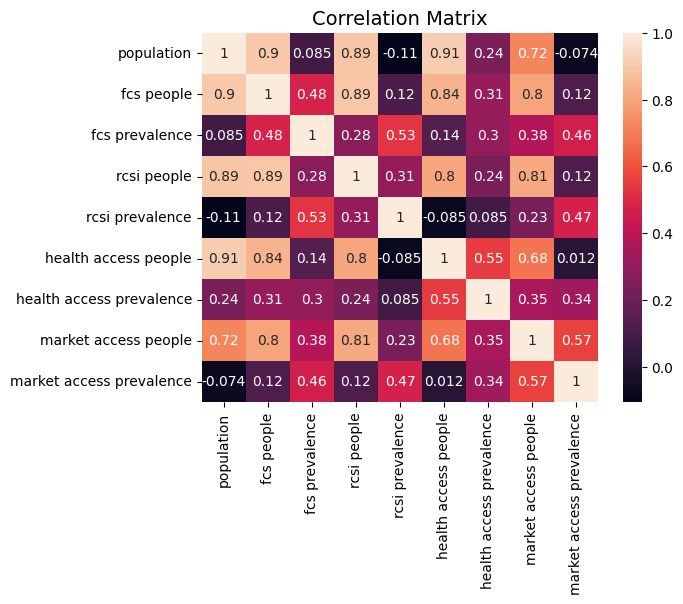

✓ Correlation matrix displayed

[INDICATOR 1] Temporal aggregation (grouping query)...
✓ Data aggregated by date
        date  fcs people  rcsi people  health access people  \
0 2024-01-05     8792908      6748693               2333131   
1 2024-01-06     8768623      6768154               2313100   
2 2024-01-07     8637837      6651572               2317579   
3 2024-01-08     8523043      6566154               2288343   
4 2024-01-09     8420603      6550754               2271646   

   market access people  
0               3225117  
1               3208684  
2               3262870  
3               3223801  
4               3249007  

[INDICATOR 2] Data transformations applied:
✓ KNN Imputation for missing values
✓ Modified Z-Score (MAD) for outlier detection
✓ Feature selection based on correlation analysis

[VISUALIZATIONS] Creating exploratory charts...


01:32:16 - cmdstanpy - INFO - Chain [1] start processing



[INDICATOR 3] FORECASTING - Temporal Analysis


01:32:16 - cmdstanpy - INFO - Chain [1] done processing


Last observed value: 8,456,947 people
Predicted in 30 days: 8,284,808 people
Change: -2.04%

[INDICATOR 4] SPATIAL CLUSTERING - Regional Analysis

Cluster assignments:
               adminone  cluster
0       Alaotra Mangoro       -1
6      Atsimo Andrefana       -1
5                 Anosy       -1
4                Androy       -1
12                Diana       -1
9             Betsiboka        0
11            Bongolava        0
16               Melaky        0
3          Analanjirofo        1
15                Itasy        1
2            Analamanga        1
8            Atsinanana        2
20       Vakinankaratra        2
19                Sofia        2
18                 Sava        2
1        Amoron I Mania        3
13      Haute Matsiatra        3
14             Ihorombe        3
17               Menabe        4
10                Boeny        4
7     Atsimo Atsinanana        5
21  Vatovavy Fitovinany        5



-----


In [ ]:
# ============================================
# MAIN BLOCK
# ============================================
if __name__ == "__main__":
    
    print("="*60)
    print("WFP HUNGERMAP - MADAGASCAR ANALYSIS")
    print("="*60)
    
    # ============================================
    # STEP 1: DATA COLLECTION
    # ============================================
    print("\n[STEP 1] Loading data...")
    file_path = "wfp-hungermap-data-for-mdg.csv"
    df = load_data(file_path)          
    print(f"✓ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # ============================================
    # STEP 2: DATA CLEANING & PREPROCESSING
    # ============================================
    print("\n[STEP 2] Data cleaning and preprocessing...")
    
    # Convertir les types + supprimer countrycode / datatype / countryname
    df = convert_types(df)             
    print("✓ Data types converted")
    
    # Compléter population avec FCS people / FCS prevalence
    df = fulfill_population(df)       
    print("✓ Population calculated from FCS data")
    
    # Imputation KNN sur population
    df = replace_NaN(df, ["population"])   
    print("✓ NaN values imputed with KNN")
    
    # Conversion de la colonne date
    df = transform_datetime(df, "date")   
    print("✓ Dates converted to datetime format")
    
    # Suppression de la date isolée 2023-12-04
    df = drop_outliers(df, "date", [pd.Timestamp("2023-12-04")])  
    print("✓ Outlier date removed")
    
    # Drop des NaN restants
    df.dropna(inplace=True)
    
    # Supprimer adminlevel si présent 
    if "adminlevel" in df.columns:
        df.drop(columns=["adminlevel"], inplace=True)
    
    print(f"✓ Cleaned data: {df.shape[0]} rows, {df.shape[1]} columns")

    df2 = df.copy()
    
    # ============================================
    # STEP 3: EXPLORATORY DATA ANALYSIS
    # ============================================
    print("\n[STEP 3] Exploratory Data Analysis...")
    plot_correlation_matrix(df)         
    print("✓ Correlation matrix displayed")
    
    # ============================================
    # STEP 4: INDICATOR 1 - GROUPING QUERY
    # ============================================
    print("\n[INDICATOR 1] Temporal aggregation (grouping query)...")
    
    aggdict = {
        "fcs people": "sum",
        "rcsi people": "sum",
        "health access people": "sum",
        "market access people": "sum",
    }
    popul_grouped = aggregate_by_date(df, "date", aggdict)   
    print("✓ Data aggregated by date")
    print(popul_grouped.head())
    
    # ============================================
    # STEP 5: INDICATOR 2 - DATA TRANSFORMATIONS
    # ============================================
    print("\n[INDICATOR 2] Data transformations applied:")
    print("✓ KNN Imputation for missing values")
    print("✓ Modified Z-Score (MAD) for outlier detection")
    print("✓ Feature selection based on correlation analysis")
    
    # ============================================
    # STEP 6: VISUALIZATIONS
    # ============================================
    print("\n[VISUALIZATIONS] Creating exploratory charts...")
    
    # Ligne multi-indicateurs
    fig1 = visualize_temporal_evolution(
        popul_grouped,
        "date",
        ["fcs people", "rcsi people", "health access people", "market access people"],
        "Food Security Indicators Over Time",
    )                                 
    fig1.show()
    
    # Aire FCS
    fig2 = visualize_area_chart(
        popul_grouped,
        "date",
        "fcs people",
        "Number of People with Insufficient Food Consumption",
    )                                  
    fig2.show()
    
    # Subplots 2x2
    fig3 = visualize_subplots_4indicators(
        popul_grouped,
        "date",
        ["fcs people", "rcsi people", "health access people", "market access people"],
    )                                  
    fig3.show()
    
    # Stacked bar par région
    grouped_region = aggregate_by_date_region(df, "date", "adminone", "fcs people")  
    fig4 = visualize_stacked_bar_by_region(
        grouped_region,
        "date",
        "adminone",
        "fcs people",
        "FCS People by Region Over Time",
    )                                  
    fig4.show()
    
    # Treemap snapshot
    fig5 = visualize_treemap_snapshot(
        grouped_region,
        "2024-01-05",
        "adminone",
        "fcs people",
        "FCS People by Region – 2024-01-05",
    )                                 
    fig5.show()
    
    # ============================================
    # STEP 7: INDICATOR 3 - FORECASTING
    # ============================================
    print("\n" + "="*60)
    print("[INDICATOR 3] FORECASTING - Temporal Analysis")
    print("="*60)
    
    df_prophet = prepare_for_prophet(popul_grouped, "date", "fcs people")   
    model, prediction = forecast_with_prophet(df_prophet, periods=30)       
    
    fig_forecast = visualize_forecast(df_prophet, prediction, title="FCS People Forecast")  
    fig_forecast.show()
    
    last_observed = df_prophet["y"].iloc[-1]
    last_predicted = prediction["yhat"].iloc[-1]
    change_pct = (last_predicted - last_observed) / last_observed * 100
    
    print(f"Last observed value: {last_observed:,.0f} people")
    print(f"Predicted in 30 days: {last_predicted:,.0f} people")
    print(f"Change: {change_pct:+.2f}%")
    
    # ============================================
    # STEP 8: INDICATOR 4 - SPATIAL CLUSTERING
    # ============================================
    print("\n" + "="*60)
    print("[INDICATOR 4] SPATIAL CLUSTERING - Regional Analysis")
    print("="*60)
    
    regional_data = aggregate_by_region(df, "adminone")     
    
    clustering_features = [
        "fcs prevalence",
        "rcsi prevalence",
        "health access prevalence",
        "market access prevalence",
    ]
    regional_clustered = spatial_clustering(regional_data, clustering_features)  
    
    print("\nCluster assignments:")
    print(regional_clustered[["adminone", "cluster"]].sort_values("cluster"))
    
    # Bar chart clusters
    fig_clusters_bar = visualize_clusters_bar(regional_clustered, "adminone")    
    fig_clusters_bar.show()
    
    # Scatter clusters
    fig_clusters_scatter = visualize_clusters_scatter(regional_clustered)         
    fig_clusters_scatter.show()
    
    print("\n" + "="*60)
    print("-----")
    print("="*60)
